In [1]:
# import requests
# import subprocess
# import tempfile
# from typing import Tuple

# def load_lidar_from_bbox(
#     bbox: Tuple[float, float, float, float],
#     api_key: str,
#     output_file: str = "lidar.laz"
# ) -> str:
#     """
#     Download LiDAR data from the OpenTopography API using a bounding box.

#     Parameters
#     ----------
#     bbox : tuple
#         Bounding box as (minx, miny, maxx, maxy) in EPSG:4326.
#     api_key : str
#         OpenTopography API key.
#     output_file : str
#         Output LAZ filename.

#     Returns
#     -------
#     str
#         Path to downloaded LiDAR file.
#     """

#     minx, miny, maxx, maxy = bbox

#     url = (
#         "https://portal.opentopography.org/API/pointcloud?"
#         f"north={maxy}&south={miny}&east={maxx}&west={minx}&"
#         f"format=LAZ&api_key={api_key}"
#     )

#     print("Downloading from:", url)
#     r = requests.get(url, stream=True)

#     if r.status_code != 200:
#         raise RuntimeError(f"Download failed ({r.status_code}): {r.text}")

#     with open(output_file, "wb") as f:
#         for chunk in r.iter_content(chunk_size=8192):
#             if chunk:
#                 f.write(chunk)

#     print(f"✅ LAZ downloaded to {output_file}")
#     return output_file



In [9]:
import os, sys
import requests
import contextily as cx
import rasterio
import matplotlib.pyplot as plt

# -----------------------
# User parameters
# -----------------------

def download_cop_dem(bbox, api_key, output_file):
    product = "COP30"

    # -----------------------
    # Build request URL
    # -----------------------
    API_URL = (
        "https://portal.opentopography.org/API/globaldem"
        f"?demtype={product}"
        f"&south={bbox['ymin']}&north={bbox['ymax']}"
        f"&west={bbox['xmin']}&east={bbox['xmax']}"
        "&outputFormat=GTiff"
        f"&API_Key={api_key}"
    )

    print("Request:", API_URL)

    # Download raster directly
    response = requests.get(API_URL, stream=True)

    if response.status_code != 200:
        print("\n❌ HTTP error:", response.status_code)
        print(response.text)
        raise SystemExit

    # Save to file
    with open(output_file, "wb") as f:
        for chunk in response.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)

    print("✅ Saved →", output_file)

def download_contextly_image(bbox):
    """
    Downloads a contextual basemap image (e.g., for visualization) for the given bounding box.

    Parameters:
    - bbox (shapely.geometry.Polygon): Bounding box as a shapely box geometry.

    Returns:
    - cx_img (ndarray): Image array of the map tiles covering the bounding box.
    """

    cx_img, ext = cx.bounds2img(bbox["xmin"],
                             bbox["ymin"],
                             bbox["xmax"],
                             bbox["ymax"],
                             ll=True,
                             source=cx.providers.CartoDB.Voyager)

    return cx_img

Request: https://portal.opentopography.org/API/globaldem?demtype=COP30&south=48.15&north=48.2&west=-1.7&east=-1.65&outputFormat=GTiff&API_Key=38b3211483d503ddd81882f2259b6201
✅ Saved → /home/renauld/DSM/data/copdem_gl30_test.tif
Checking file size...
{'driver': 'GTiff', 'dtype': 'float32', 'nodata': None, 'width': 180, 'height': 180, 'count': 1, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(0.0002777777777777778, 0.0, -1.7001388999999847,
       0.0, -0.0002777777777777778, 48.2001389), 'blockxsize': 256, 'blockysize': 256, 'tiled': True, 'compress': 'lzw', 'interleave': 'band'}


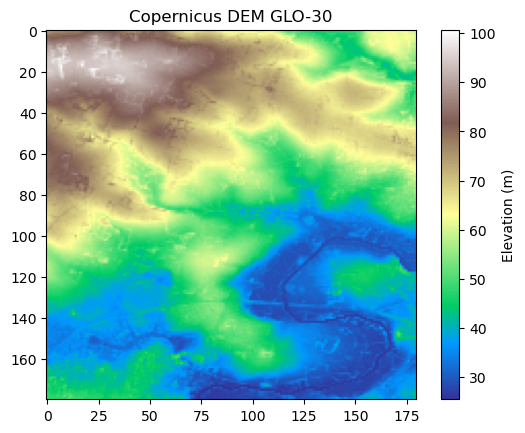

In [10]:
base_dir = "/home/renauld/DSM/"
data_dir = os.path.join(base_dir, "data")
output_file = os.path.join(data_dir, "copdem_gl30_test.tif")

bbox = {
    "xmin": -1.7,
    "ymin": 48.15,
    "xmax": -1.65,
    "ymax": 48.2
}
api_key = "38b3211483d503ddd81882f2259b6201"   # <-- put your key here

download_cop_dem(bbox, api_key, output_file)

print("Checking file size...")

with rasterio.open(output_file) as src:
    dem = src.read(1)
    profile = src.profile
    print(profile)

plt.imshow(dem, cmap="terrain")
plt.colorbar(label="Elevation (m)")
plt.title("Copernicus DEM GLO-30")
plt.show()

    

In [ ]:
def download_lidar(bbox, api_key, out_dir="lidar_download"):
    """
    Download LiDAR tiles from OpenTopography using a bounding box.

    bbox = { "xmin": ..., "ymin": ..., "xmax": ..., "ymax": ... }
    """

    # ensure folder exists
    os.makedirs(out_dir, exist_ok=True)

    # -----------------------
    # Build request URL
    # -----------------------
    API_URL = (
        "https://portal.opentopography.org/API/las?"
        f"product=pointcloud"
        f"&south={bbox['ymin']}&north={bbox['ymax']}"
        f"&west={bbox['xmin']}&east={bbox['xmax']}"
        f"&outputFormat=LAZ"
        f"&API_Key={api_key}"
    )

    print("→ Request:", API_URL)

    response = requests.get(API_URL)

    if response.status_code != 200:
        print("❌ API error:", response.status_code, response.text)
        return

    data = response.json()

    # Validate response
    if "result" not in data or "files" not in data["result"]:
        print("❌ Unexpected API response:", data)
        return

    files = data["result"]["files"]

    if len(files) == 0:
        print("⚠️ No LiDAR tiles found for this bounding box.")
        return

    print(f"✅ {len(files)} tiles found")

    # Download all tiles
    for item in files:
        url = item["url"]
        fname = os.path.join(out_dir, os.path.basename(url))

        print("↓ Downloading:", fname)

        r = requests.get(url, stream=True)
        if r.status_code != 200:
            print("❌ Failed:", url)
            continue

        with open(fname, "wb") as f:
            for chunk in r.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)

    print("\n✅ Finished downloading LiDAR")

In [15]:
download_lidar(bbox, api_key)

→ Request: https://portal.opentopography.org/API/las?product=pointcloud&south=48.15&north=48.2&west=-1.7&east=-1.65&outputFormat=LAZ&API_Key=38b3211483d503ddd81882f2259b6201
❌ API error: 404 <!doctype html><html lang="en"><head><title>HTTP Status 404 – Not Found</title><style type="text/css">body {font-family:Tahoma,Arial,sans-serif;} h1, h2, h3, b {color:white;background-color:#525D76;} h1 {font-size:22px;} h2 {font-size:16px;} h3 {font-size:14px;} p {font-size:12px;} a {color:black;} .line {height:1px;background-color:#525D76;border:none;}</style></head><body><h1>HTTP Status 404 – Not Found</h1><hr class="line" /><p><b>Type</b> Status Report</p><p><b>Message</b> Not Found</p><p><b>Description</b> The origin server did not find a current representation for the target resource or is not willing to disclose that one exists.</p><hr class="line" /><h3>Apache Tomcat/9.0.88</h3></body></html>


In [17]:
import os
import requests
import geopandas as gpd
import rasterio
from shapely.geometry import box

def download_raster_tiles(tile_index_shapefile, product_type, bbox, out_dir="lidar_tiles"):
    """
    Download IGN LiDAR‑HD raster tiles for a given bounding box.
    
    Parameters:
      tile_index_shapefile : str : path to shapefile or GeoPackage that lists all tiles with URLs
      product_type : str : one of "MNT", "MNS", "MNH"
      bbox : dict with keys xmin, ymin, xmax, ymax in the projection of the tile index
      out_dir : directory to save tiles
    """
    os.makedirs(out_dir, exist_ok=True)
    
    # Load tile index
    tiles = gpd.read_file(tile_index_shapefile)
    
    # Filter tiles that intersect the bbox
    bbox_geom = box(bbox["xmin"], bbox["ymin"], bbox["xmax"], bbox["ymax"])
    sel = tiles[tiles.intersects(bbox_geom)]
    print(f"Found {len(sel)} tiles to download")
    
    for idx, row in sel.iterrows():
        url = row[f"url_{product_type}"]  # you’ll need to know which column has the link URL
        fname = os.path.join(out_dir, os.path.basename(url))
        if os.path.exists(fname):
            print(f"Already exists: {fname}")
            continue
        print(f"Downloading {url} to {fname}")
        r = requests.get(url, stream=True)
        if r.status_code != 200:
            print("Failed download:", url, r.status_code)
            continue
        with open(fname, "wb") as f:
            for chunk in r.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)
    print("Done.")

def stitch_tiles(tile_files, out_raster_path, resampling=None):
    """
    (Optional) Read multiple GeoTIFF tile_files and merge them into one raster.
    You can use rasterio.merge.merge for this.
    """
    import rasterio
    from rasterio.merge import merge
    
    src_files_to_mosaic = []
    for fp in tile_files:
        src = rasterio.open(fp)
        src_files_to_mosaic.append(src)
    mosaic, out_trans = merge(src_files_to_mosaic, res=resampling)
    
    out_meta = src.meta.copy()
    out_meta.update({
        "driver": "GTiff",
        "height": mosaic.shape[1],
        "width": mosaic.shape[2],
        "transform": out_trans
    })
    with rasterio.open(out_raster_path, "w", **out_meta) as dest:
        dest.write(mosaic)
    print("Stitched raster written to", out_raster_path)

if __name__ == "__main__":
    # Example bounding box in Lam­bert 93 / IGN69
    bbox = {
      "xmin": 600000, "ymin": 2420000,
      "xmax": 610000, "ymax": 2430000
    }
    tile_index = "home/renauld/data/ign_lidarhd_tiles.shp"
    out_dir = os.path.join(base_dir, "lidar_tiles")
    download_raster_tiles(tile_index, product_type="MNS", bbox=bbox, out_dir=out_dir)
    # Then list downloaded files and stitch:
    # tile_files = [ … list of .tif files in my_tiles … ]
    # stitch_tiles(tile_files, "stitched_MNS.tif", resampling=None)


DataSourceError: home/renauld/data/ign_lidarhd_tiles.shp: No such file or directory